In [2]:
import sys
sys.path.append('/home/jianchao/ros_workspace/prior_nbv/src')
import open3d as o3d
import os
import numpy as np
from networks.src.networks.chamfer import chamfer_distance
import torch
from torch_scatter import scatter_mean

def get_chamfer_dists(pcd_x, pcd_y):
    # We compare the two sets of pointclouds by computing the chamfer loss.
    _, _, dist_x, dist_y = chamfer_distance(pcd_x, pcd_y)
    dist_x = dist_x.cpu().detach()
    dist_y = dist_y.cpu().detach()

    return dist_x, dist_y

def cal_coverage2(partial_pc, complete_pc):
    _, dist2 = get_chamfer_dists(partial_pc[..., 0:3], complete_pc)
    covered_points = dist2 < 0.003
    cov_ratio = torch.sum(covered_points).item() / covered_points.shape[1]
    return '%s/%s' % (str(torch.sum(covered_points).item()),
                        str(covered_points.shape[1])), cov_ratio

def point_cloud_down_sampling(points, voxel_size):
    # Convert points to tensors and move them to GPU if available
    points = torch.tensor(points, dtype=torch.float32)
    points = points.cuda()

    num_channels = points.shape[1]  # Get the number of channels

    # Apply voxel grid downsampling
    voxel_indices = torch.floor(points[:, :3] / voxel_size)
    unique_indices, inverse_indices = torch.unique(voxel_indices, return_inverse=True, dim=0)

    downsampled_points = scatter_mean(points, inverse_indices, dim=0)

    # Adjust the number of channels based on the input point cloud
    if num_channels == 3:
        downsampled_points = downsampled_points[:, :3]  # Keep only the XYZ coordinates
    elif num_channels == 6:
        downsampled_points = downsampled_points[:, :6]  # Keep all the XYZ coordinates and additional channels

    return downsampled_points#.cpu().numpy()

def load_complete_pc(complete_plant_dir, plant, plant_idx, plant_rotation, plant_position = [0,0,0], scale = 1):
        print('loading complete point cloud of [tomato%s]' %
              (str(plant_idx) + '_r(%d)' % int(plant_rotation) + '_t(%d_%d_%d)'%(int(plant_position[0]), int(plant_position[1]), int(plant_position[2]))))
        plant_path = os.path.join(complete_plant_dir,
                                  plant + str(plant_idx) + '.pcd')

        pcd = o3d.io.read_point_cloud(plant_path)
        pcd.scale(scale, center=(0.0, 0.0, 0.0))

        T = np.eye(4)
        T[:3,:3] = pcd.get_rotation_matrix_from_xyz((0, 0, plant_rotation)) 
        T[0:3,3] = np.array(plant_position)/100

        pcd = pcd.transform(T)
        points = np.asarray(pcd.points).astype(np.float32)
        points = point_cloud_down_sampling(points, 0.003).reshape(1, -1, 3)
        return points

x_offset = -20
y_offset = -20
rotation = 0
plant_idx = 1
complete_plant_dir = '/home/jianchao/ros_workspace/prior_nbv/src/greenhouse_gazebo/gt_pcd'
partial_dir = f'/home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Fri May 30 16:39:59 2025/plant{plant_idx}/xyr_{x_offset}_{y_offset}_{rotation}/pcd'

complete_pcd = load_complete_pc(complete_plant_dir, 'plant', plant_idx, rotation, plant_position=[x_offset, y_offset, 0], scale=1)
print(complete_pcd.shape)

partial_pcds_numpy = []
for file in os.listdir(partial_dir):
    if file.endswith(".npy"):
        partial_pcds_numpy.append(np.load(os.path.join(partial_dir, file))[0])

partial_pcds_numpy = np.array(partial_pcds_numpy, dtype=list)
partial_pcds_numpy = np.concatenate(partial_pcds_numpy, axis=0)#.reshape(1, -1, 3)
partial_pcds_numpy_downsampled = point_cloud_down_sampling(partial_pcds_numpy, 0.003).unsqueeze(0)
print(partial_pcds_numpy_downsampled.shape)

covered_points, ratio = cal_coverage2(partial_pc=partial_pcds_numpy_downsampled, complete_pc=complete_pcd)
print(ratio)
print(covered_points)

#visualize complete_pcd and partial_pcd in different colors using open3d
complete_pcd_o3d = o3d.geometry.PointCloud()
complete_pcd_o3d.points = o3d.utility.Vector3dVector(complete_pcd[0].cpu().numpy())
complete_pcd_o3d.paint_uniform_color([0, 0, 1])

partial_pcd_o3d = o3d.geometry.PointCloud()
partial_pcd_o3d.points = o3d.utility.Vector3dVector(partial_pcds_numpy_downsampled[0,:, 0:3].cpu().numpy())
partial_pcd_o3d.paint_uniform_color([1, 0, 0])

o3d.visualization.draw_geometries([complete_pcd_o3d, partial_pcd_o3d])



Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


ModuleNotFoundError: No module named 'networks'

In [1]:
!source /home/jianchao/ros_workspace/paper4_semantic_nbv/devel/setup.bash

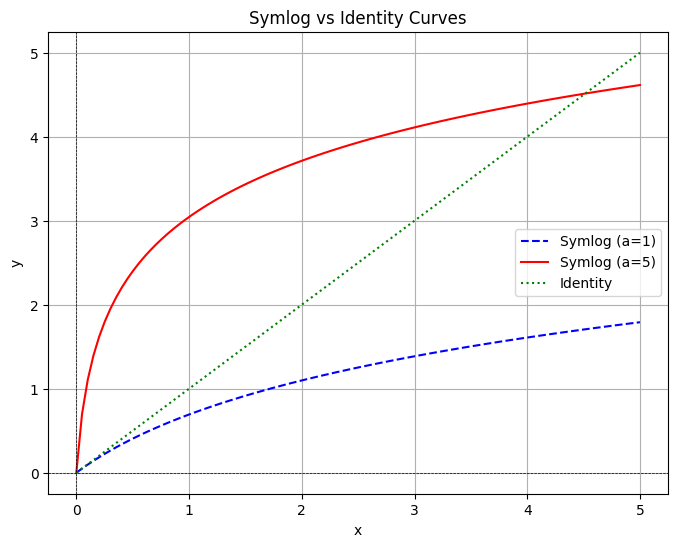

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def symlog(x, a=1):
    """
    Modified symlog function with parameter `a` to control steepness near x=0.
    """
    return torch.sign(x) * torch.log(torch.abs(x) * a + 1)

# Generate the input data
x = torch.linspace(0, 5, 100)

# Original symlog curve
y_original = symlog(x, a=1)

# Modified symlog curve with higher sensitivity near x=0
y_modified = symlog(x, a=20)  # Adjust `a` to control the steepness

# Plot the curves
plt.figure(figsize=(8, 6))
plt.plot(x.numpy(), y_original.numpy(), label="Symlog (a=1)", linestyle="--", color="blue")
plt.plot(x.numpy(), y_modified.numpy(), label="Symlog (a=5)", linestyle="-", color="red")
plt.plot(x.numpy(), x.numpy(), label="Identity", linestyle=":", color="green")

plt.axhline(0, color="black", linewidth=0.5, linestyle="--")
plt.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.title("Symlog vs Identity Curves")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()


In [34]:
import collections

# Create a deque with max length 100
buffer = collections.deque(maxlen=100)

# Example: Populate the deque with some elements
buffer.append([1, 2, 3, 4, 5])
buffer.append([6, 7, 8, 9, 10])

# Replace element at a specific index
index_to_replace = 1
new_element = [3, 42, 3, 4, 5]
temp_list = list(buffer)
temp_list[index_to_replace] = new_element  # Replace at index 1
buffer = collections.deque(temp_list, maxlen=100)

print(buffer)  # Output: deque([1, 42, 3, 4, 5], maxlen=100)


deque([[1, 2, 3, 4, 5], [3, 42, 3, 4, 5]], maxlen=100)


In [48]:
# viewstate = torch.tensor([0, 0, 1, 0])
# viewstate = viewstate.unsqueeze(0)
# #convert to one hot
# viewstate = torch.nn.functional.one_hot(viewstate, num_classes=4)
# print(viewstate)


# a = torch.arange(0, viewstate.shape[1]).unsqueeze(0)
# batch_size = 2
# print(a)
# # convert a to one hot
# a = torch.nn.functional.one_hot(a, num_classes=a.shape[1])
# a = a.repeat(batch_size, 1, 1)
# print(a)

next_hiddens = torch.tensor([[[1, 2, 3],[3,4, 5]], [[4, 5, 6],[7,8,9]]])
index  = torch.tensor([0, 1])
print(next_hiddens.shape)
print(index.shape)
# get the hidden state at the index
out = next_hiddens[torch.arange(next_hiddens.size(0)), index]
print(out)
print(out.shape)




torch.Size([2, 2, 3])
torch.Size([2])
tensor([[1, 2, 3],
        [7, 8, 9]])
torch.Size([2, 3])


Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_-10_-20_0_180/depth
Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_20_-20_20_0/depth
Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_-20_0_0_180/depth
Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_-20_0_20_0/depth
Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_0_0_20_0/depth
Deleted: /home/jianchao/ros_workspace/paper4_semantic_nbv/src/offline_experiments/materials/view_data_collection/Mon Jun  2 16:52:47 2025/plant2/xyzr_-10_0_20_180

In [ ]:
#read depth and rgb image in .npy file and save as .png file in the given folder

def generate_cloud_data_common(bgr_img_, depth_img_):
        bgr_img = bgr_img_.copy()
        depth_img = depth_img_.copy()
        
        width = 960
        height = 540

      

        # Camera intrinsic matrix
        fx = 1318.7885474736386
        fy = 1318.7885474736386
        cx = 480.5
        cy = 270.5

        intrinsic = np.matrix([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]],
                              dtype=np.float32)
        
        # geneate the ponit cloud based on the depth and rgb image
        xyz = np.zeros((height, width, 3))

        for i in range(height):
            for j in range(width):
                z = depth_img[i, j]
                x = (j - cx) * z / fx
                y = (i - cy) * z / fy
                xyz[i, j, :] = [x, y, z]
        
        # remove the nan value
        xyz = xyz[~np.isnan(xyz)]
        xyz = xyz.reshape(-1, 3)
        #remove the points with z > 1.5
        xyz = xyz[xyz[:, 2] < 1.5]

        return xyz

import cv2.samples
import numpy as np
import cv2
import os

part_pcd_dir = '/home/jianchao/dataset/nbv_data/paper4/data_smaller_fov_distance'
complete_pcd_dir = '/home/jianchao/dataset/nbv_data/paper4/data_complete'

plant_index = 5
x = 0
y = 0
h = 0
rotation = 0

row_range = 6
col_range = 4

depth_path = os.path.join(part_pcd_dir, 'plant%s'%str(plant_index), 'xyzr_%s_%s_%s_%s' % (str(x), str(y), str(h), str(rotation)), 'depth', 'depth_%s_%s.npy' % (str(row_range), str(col_range)))
rgb_path = os.path.join(part_pcd_dir, 'plant%s'%str(plant_index), 'xyzr_%s_%s_%s_%s' % (str(x), str(y), str(h), str(rotation)), 'rgb', 'rgb_%s_%s.npy' % (str(row_range), str(col_range)))
#read depth and rgb image in .npy file and save as .png file in the given folder
depth_image = 255-np.load(depth_path)/1.5*255
rgb_image = np.load(rgb_path)

# save the images in path /home/jianchao/ros_workspace/paper4_semantic_nbv/preliminary_results
# save rgb and depth image in the given folder
cv2.imwrite("/home/jianchao/ros_workspace/paper4_semantic_nbv/preliminary_results/depth_%s_%s.png" % (str(row_range), str(col_range)), depth_image)
cv2.imwrite("/home/jianchao/ros_workspace/paper4_semantic_nbv/preliminary_results/rgb_%s_%s.png" % (str(row_range), str(col_range)), rgb_image)


[[  0.        0.        0.      ...   0.        0.        0.     ]
 [  0.        0.        0.      ...   0.        0.        0.     ]
 [  0.        0.        0.      ...   0.        0.        0.     ]
 ...
 [154.4594  154.4812  154.50299 ...   0.        0.        0.     ]
 [154.53021 154.55197 154.57373 ...   0.        0.        0.     ]
 [154.60051 154.62265 154.64478 ...   0.        0.        0.     ]]


True